In [61]:
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as colors
import arviz as az
from scipy.stats import gaussian_kde
from pesummary.io import read
from simple_pe.param_est import SimplePESamples
from simple_pe.waveforms import parameter_bounds, make_waveform

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [3]:
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'ecc10sqrd': 0.2**2, 'chi_align': 0.2}
f_low = 10
srate = 4096
tlen = 32
df = 1/tlen
flen = int(tlen*srate)//2 + 1
hp, hc = make_waveform(params, df, f_low, flen, approximant='TEOBResumS-Dali', return_hc=True)
h = hp.to_timeseries() - 1j*hc.to_timeseries()
harms_fs = make_waveform(params, df, f_low, flen, approximant='TEOBResumS-Dali-Harms', n_ecc_gen=10, n_ecc_harms=4, orthonormalize_ecc_harms=False)
harms = {key: harms_fs[key].to_timeseries() for key in harms_fs.keys()}

2026-03-06  15:37:58 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-03-06  15:37:58 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default
2026-03-06  15:38:00 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-03-06  15:38:00 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


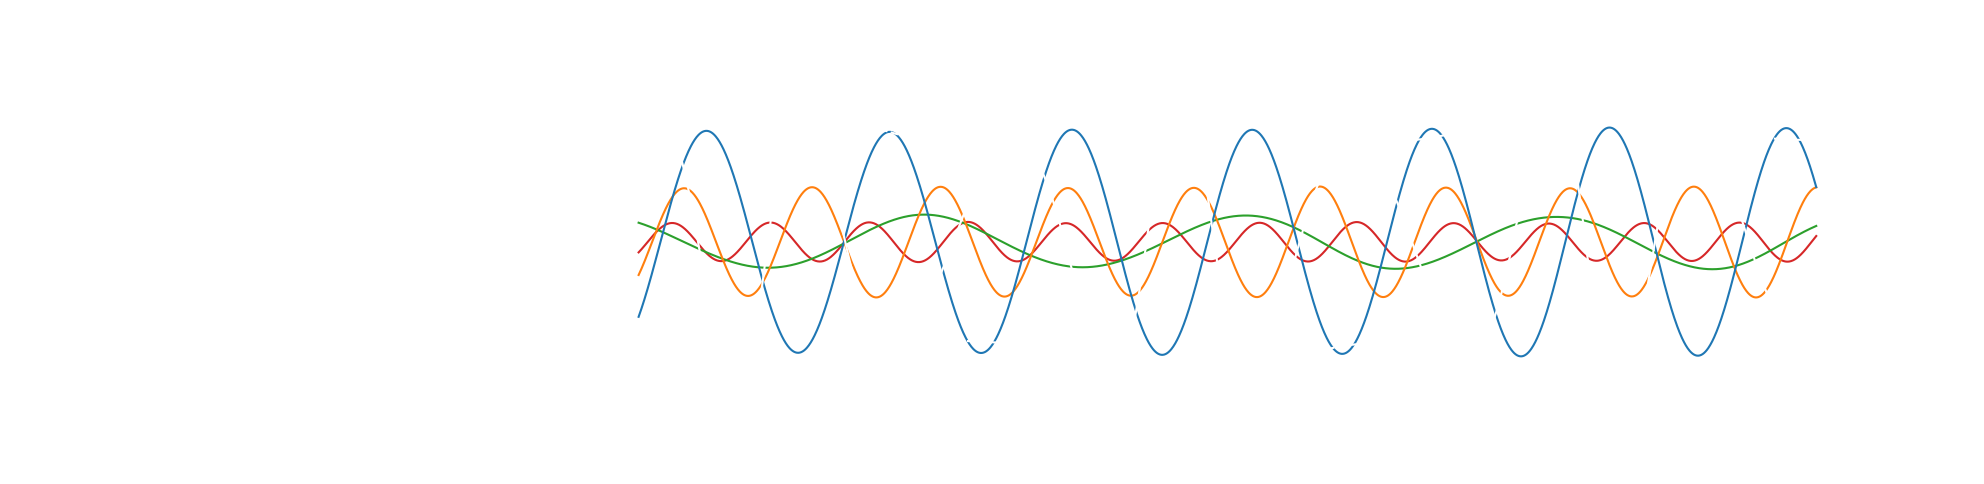

In [7]:
# Set times for each waveform
h_times = [-5.5, -4.5]
harm_times = [-5.18, -4.58]
h_inds = [np.argmin(np.abs(h_times[i]-h.sample_times)) for i in [0, 1]]
harm_inds = [np.argmin(np.abs(harm_times[i]-harms[0].sample_times)) for i in [0, 1]]

# Make plot
plt.figure(figsize=(20, 5))
plt.plot(h.sample_times[h_inds[0]:h_inds[1]], h[h_inds[0]:h_inds[1]], c='w', zorder=5)
plt.plot(h.sample_times[harm_inds[0]:harm_inds[1]], np.abs(h)[harm_inds[0]:harm_inds[1]], c='w', zorder=5, ls='dashed')
plt.plot(h.sample_times[harm_inds[0]:harm_inds[1]], -np.abs(h)[harm_inds[0]:harm_inds[1]], c='w', zorder=5, ls='dashed')
for i, key in enumerate(harms.keys()):
    plt.plot(harms[key].sample_times[harm_inds[0]:harm_inds[1]], harms[key][harm_inds[0]:harm_inds[1]], zorder=4-i)
plt.xlim(h_times[0], h_times[1])
plt.ylim(-2e-19, 2e-19)
plt.axis('off')
plt.tight_layout()
plt.savefig('Figures/harm_decomp.png', dpi=1000, transparent=True)
plt.show()

In [100]:
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import arviz as az
from scipy.stats import gaussian_kde
from pesummary.io import read
from simple_pe.param_est import SimplePESamples
from simple_pe.waveforms import parameter_bounds

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [90]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def summary_plot(delta_lbl, inj_lbl, colour_lbl, injections_dir, err_type, resample_log_2_uni=False, use_hdi=True, xlims=None, ylims=None):

    # Loop through injections:
    inj_params = []
    delta_meds = []
    delta_errs = []
    c_vals = []
    failed_inds = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):
        inj_dir = os.path.join(injections_dir, inj_dir)
        inj_dir = os.path.join(inj_dir, 'outdir/output/')
        
        # Get inj_param, delta_true, and c_val
        inj_path = os.path.join(inj_dir, 'converted_injection_parameters.json')
        with open(inj_path, 'r') as f:
            inj_dict = json.load(f)
        inj_param = inj_dict['posterior_samples'][inj_lbl]
        delta_true = inj_dict['posterior_samples'][delta_lbl]
        c_val = inj_dict['posterior_samples'][colour_lbl]
        inj_params.append(inj_param)
        c_vals.append(c_val)

        # Check run finished properly, if so get samples on delta parameter
        if 'posterior_samples.dat' not in os.listdir(inj_dir) or inj_dict['posterior_samples']['network'][0] < 12:
            failed_inds.append(i)
        else:
            samples_path = os.path.join(inj_dir, 'posterior_samples.dat')
            samples = SimplePESamples(read(samples_path).samples_dict)
            samples.generate_all_posterior_samples()
            samples_delta = samples[delta_lbl]
            if resample_log_2_uni:
                weights = samples_delta.copy()
                weights[weights<=0.02] = 0.02
                weights /= np.max(weights)
                samples_delta = samples_delta[np.random.uniform(0, 1, len(samples_delta)) < weights]
            if use_hdi:
                hdi = az.hdi(samples_delta, prob=0.9)
                if hdi[0] < 0.005:
                    hdi[0] = 0
                samples_kde = gaussian_kde(samples_delta)
                delta_arr = np.linspace(np.min(samples_delta), np.max(samples_delta), 1001)
                peak = delta_arr[np.argmax(samples_kde(delta_arr))]
                pts = np.array([hdi[0], peak, hdi[1]])
            else:
                pts = np.quantile(samples_delta, [0.05, 0.5, 0.95])
            if err_type == 'rel':
                pts /= delta_true
            elif err_type == 'abs':
                pts -= delta_true
            elif err_type == 'base':
                if delta_lbl != inj_lbl:
                    raise ValueError('delta_lbl must equal inj_lbl for base err_type')
                pts = pts
            else:
                raise ValueError('Incorrect err_type')
            delta_meds.append(pts[1])
            delta_errs.append([pts[1] - pts[0], pts[2] - pts[1]])

    # Plot failed runs
    plt.figure(figsize=(6.4, 4))
    # for ind in failed_inds:
    #     plt.axvline(inj_params[ind], c='r', lw=1)
    inj_params = np.delete(inj_params, failed_inds)
    c_vals = np.delete(c_vals, failed_inds)

    # Plot errors
    cmap = plt.get_cmap('plasma')
    new_cmap = truncate_colormap(cmap, 0.3, 1)
    sc = plt.scatter(inj_params, delta_meds, c=c_vals, cmap=new_cmap, vmin=12, vmax=24)
    clb = plt.colorbar(sc, label=f'Injected {colour_lbl}', extend='max')
    clb.ax.tick_params(color='w', labelcolor='w')
    for spine in clb.ax.spines.values():
        spine.set_edgecolor('w')
    clb.ax.set_yticks([12, 15, 18, 21, 24])
    norm = matplotlib.colors.Normalize(vmin=12, vmax=24)
    mapper = cm.ScalarMappable(norm=norm, cmap=new_cmap)
    c_arr = np.array([(mapper.to_rgba(c_val)) for c_val in c_vals])
    for x, y, e, c in zip(inj_params, delta_meds, delta_errs, c_arr):
        plt.errorbar(x, y, yerr=np.array([e]).T, color=c, capsize=5)

    # Plot invalid regions of identical parameters (assume default param bounds)
    plt.xlim(xlims)
    plt.ylim(ylims)
    xlims = plt.gca().get_xlim()
    ylims = plt.gca().get_ylim()
    if delta_lbl == inj_lbl:
        param_mins = SimplePESamples(parameter_bounds.param_mins)
        param_maxs = SimplePESamples(parameter_bounds.param_maxs)
        param_mins.generate_all_posterior_samples()
        param_maxs.generate_all_posterior_samples()
        min_param = param_mins[delta_lbl]
        max_param = param_maxs[delta_lbl]
        if min_param > max_param:
            min_param, max_param = max_param, min_param
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        if err_type == 'rel':
            min_bound = min_param / x_arr
            max_bound = max_param / x_arr
        elif err_type == 'abs':
            min_bound = min_param - x_arr
            max_bound = max_param - x_arr
        elif err_type == 'base':
            min_bound = min_param
            max_bound = max_param
        plt.fill_between(x_arr, ylims[0], min_bound, color='k', alpha=1, zorder=0)
        plt.fill_between(x_arr, max_bound, ylims[1], color='k', alpha=1, zorder=0)

    # Plot formatting
    plt.xlabel(f'Injected {inj_lbl}', color='w')
    if err_type == 'rel':
        plt.axhline(1, c='w', ls='dashed')
        plt.ylabel(f'Relative {delta_lbl} error', color='w')
    elif err_type == 'abs':
        plt.axhline(0, c='w', ls='dashed')
        plt.ylabel(f'Absolute {delta_lbl} error', color='w')
    elif err_type == 'base':
        xlims = plt.gca().get_xlim()
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        plt.plot(x_arr, x_arr, c='w', ls='dashed')
        plt.ylabel(f'Recovered {delta_lbl}', color='w')
    plt.gca().set_facecolor('#00001E')
    plt.gcf().patch.set_facecolor('#00001E')
    plt.gca().tick_params(color='w', labelcolor='w')
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('w')
    plt.gca().set_xticks([0, 0.1, 0.2, 0.3, 0.4])
    plt.gca().set_yticks([0, 0.1, 0.2, 0.3, 0.4])
    plt.tight_layout()
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.savefig('Figures/summary_eccs.png', dpi=1000, transparent=True)
    plt.show()

50it [00:09,  5.42it/s]


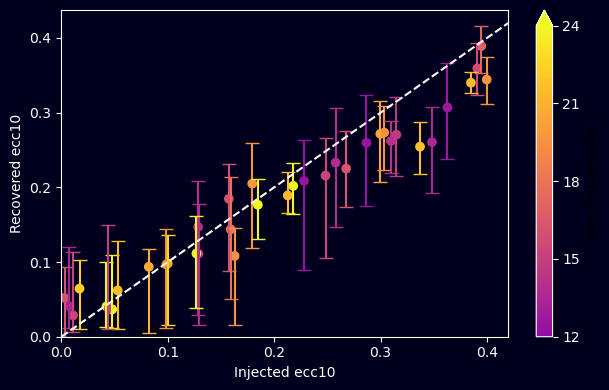

In [92]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v2/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, resample_log_2_uni=True, xlims=xlims, ylims=ylims)